In [2]:
%pip install numpy pandas matplotlib seaborn scikit-learn --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
#Load dataset
import pandas as pd
train_df = pd.read_csv('sample.csv')

#Basic EDA
print(train_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   stationId              309 non-null    int64  
 1   destination_stationId  309 non-null    int64  
 2   hour                   309 non-null    int64  
 3   lat                    309 non-null    float64
 4   lng                    309 non-null    float64
 5   destination_lat        309 non-null    float64
 6   destination_lng        309 non-null    float64
 7   delta_time             309 non-null    float64
dtypes: float64(5), int64(3)
memory usage: 19.4 KB
None


In [4]:
train_df["delta_time"].describe(include='all')

count    309.000000
mean     188.304376
std       76.807447
min       74.199850
25%      143.994139
50%      170.172401
75%      208.990548
max      891.276558
Name: delta_time, dtype: float64

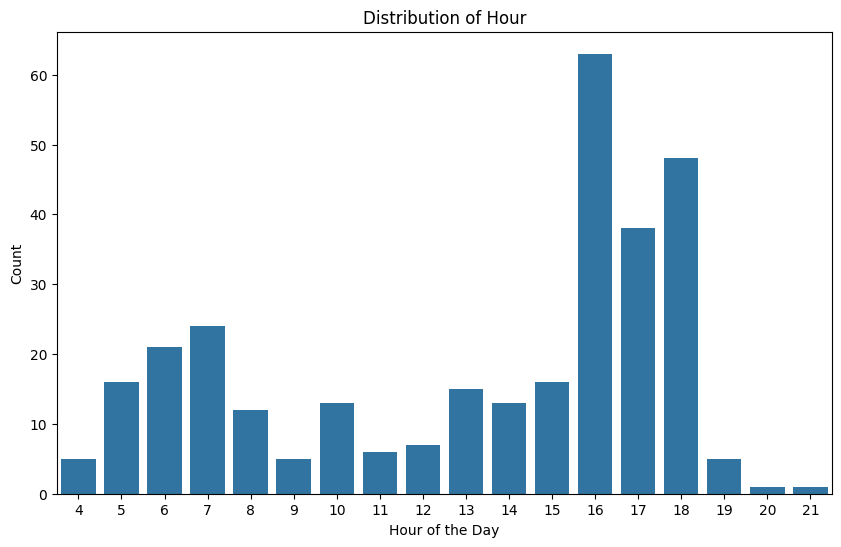

In [5]:
#hour distribution
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.countplot(x='hour', data=train_df)
plt.title('Distribution of Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Count')
plt.show()

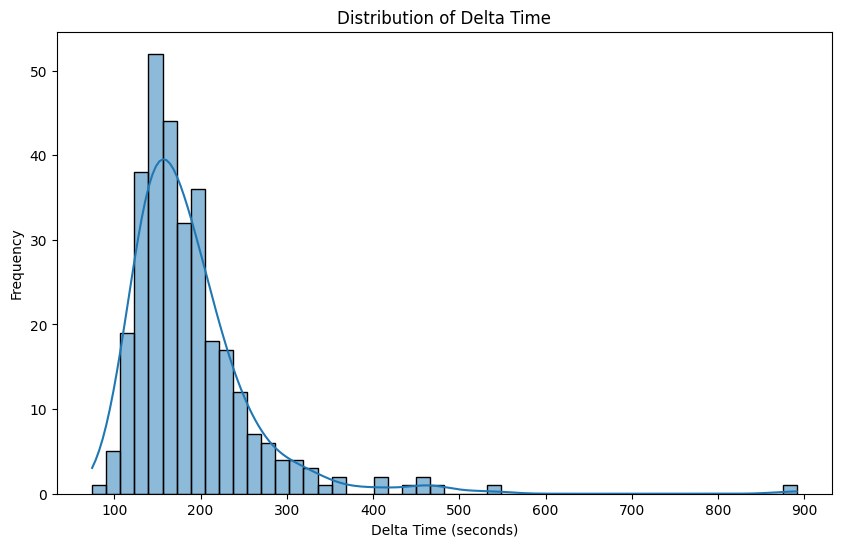

In [6]:
#delta time (only) histogram
plt.figure(figsize=(10, 6))
sns.histplot(train_df['delta_time'], bins=50, kde=True)
plt.title('Distribution of Delta Time')
plt.xlabel('Delta Time (seconds)')
plt.ylabel('Frequency')
plt.show()

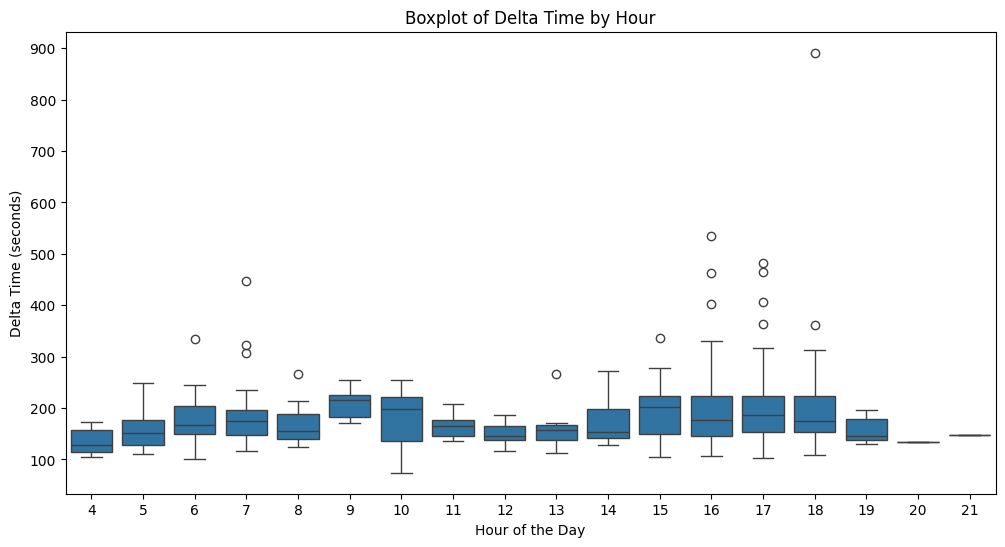

In [7]:
#boxplot of delta_time by hour
plt.figure(figsize=(12, 6))
sns.boxplot(x='hour', y='delta_time', data=train_df)
plt.title('Boxplot of Delta Time by Hour')
plt.xlabel('Hour of the Day')
plt.ylabel('Delta Time (seconds)')
plt.show()

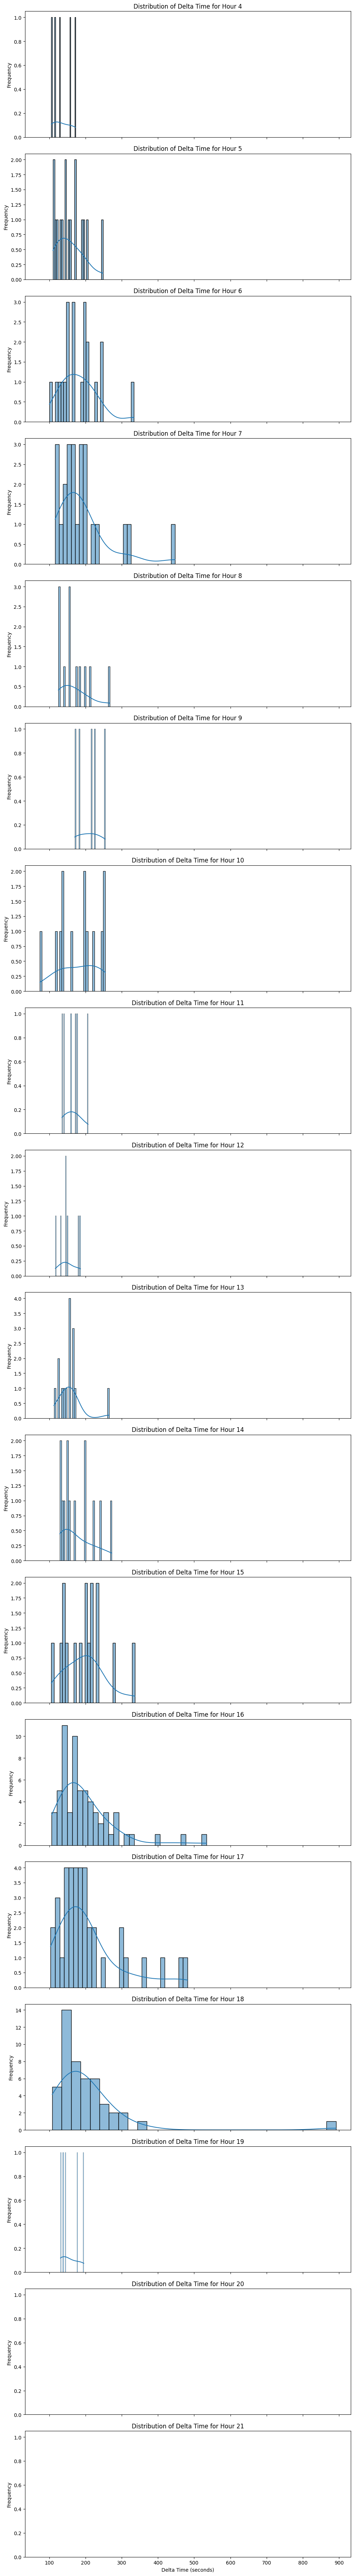

In [12]:
#histogram of delta_time by hour (sử dụng nhiều plots, nhiều histogram đơn lẻ thay vì gộp vào một plot, không dùng grid, tách thành n bảng)

unique_hours = train_df['hour'].unique()
num_hours = len(unique_hours)
fig, axes = plt.subplots(num_hours, 1, figsize=(10, num_hours * 4), sharex=True)
for i, hour in enumerate(sorted(unique_hours)):
    sns.histplot(train_df[train_df['hour'] == hour]['delta_time'], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of Delta Time for Hour {hour}')
    axes[i].set_xlabel('Delta Time (seconds)')
    axes[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()


In [30]:
#Cosine Encoding for hour

import numpy as np

copy_df = train_df.copy()
copy_df["hour_sin"] = np.sin(2 * np.pi * copy_df["hour"] / 24)
copy_df["hour_cos"] = np.cos(2 * np.pi * copy_df["hour"] / 24)
print(copy_df[["hour", "hour_sin", "hour_cos"]].head())

   hour  hour_sin      hour_cos
0    14 -0.500000 -8.660254e-01
1    16 -0.866025 -5.000000e-01
2    18 -1.000000 -1.836970e-16
3    14 -0.500000 -8.660254e-01
4     7  0.965926 -2.588190e-01


In [31]:
from sklearn.model_selection import train_test_split

X = copy_df[["hour", "hour_sin", "hour_cos"]]
y = copy_df["delta_time"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [32]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    return {
        "model": name,
        "MAE": mae,
        "RMSE": rmse
    }

In [33]:
# Global mean

global_mean = y_train.mean()

y_pred_global_mean = np.full(shape=len(y_test), fill_value=global_mean)

# Global median
global_median = y_train.median()

y_pred_global_median = np.full(shape=len(y_test), fill_value=global_median)

In [34]:
#Mean by hour
train_df = X_train.copy()
train_df["delta_time"] = y_train

mean_by_hour = train_df.groupby("hour")["delta_time"].mean()

y_pred_mean_by_hour = X_test["hour"].map(mean_by_hour)
y_pred_mean_by_hour = y_pred_mean_by_hour.fillna(global_mean)

In [35]:
#Median by hour
median_by_hour = train_df.groupby("hour")["delta_time"].median()

y_pred_median_by_hour = X_test["hour"].map(median_by_hour)
y_pred_median_by_hour = y_pred_median_by_hour.fillna(global_median)

In [36]:
#Ridge Regression
import numpy as np
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error

model = Ridge(alpha=1.0)
model.fit(X_train, y_train)
y_pred_ridge = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae = mean_absolute_error(y_test, y_pred_ridge)
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

Root Mean Squared Error: 67.86
Mean Absolute Error: 48.44


In [37]:
# Cross-validation for Ridge and simple baselines
import numpy as np
import pandas as pd
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_validate

cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Ridge Regression": Ridge(alpha=1.0),
    "Dummy Mean": DummyRegressor(strategy="mean"),
    "Dummy Median": DummyRegressor(strategy="median"),
}

scoring = {
    "MAE": "neg_mean_absolute_error",
    "MSE": "neg_mean_squared_error",
}

cv_results = []
for name, estimator in models.items():
    scores = cross_validate(estimator, X, y, cv=cv, scoring=scoring)
    mae = -scores["test_MAE"].mean()
    rmse = np.sqrt(-scores["test_MSE"].mean())
    cv_results.append({"model": name, "CV_MAE": mae, "CV_RMSE": rmse})

cv_results_df = pd.DataFrame(cv_results).sort_values("CV_MAE")
cv_results_df

,model,CV_MAE,CV_RMSE
2,Dummy Median,46.880082,78.900006
1,Dummy Mean,48.988369,76.898307
0,Ridge Regression,50.090875,77.426372


In [38]:
results = []

results.append(evaluate_model(
    "Global Mean",
    y_test,
    y_pred_global_mean
))

results.append(evaluate_model(
    "Global Median",
    y_test,
    y_pred_global_median
))

results.append(evaluate_model(
    "Mean by Hour",
    y_test,
    y_pred_mean_by_hour
))

results.append(evaluate_model(
    "Median by Hour",
    y_test,
    y_pred_median_by_hour
))

results.append(evaluate_model(
    "Ridge Regression",
    y_test,
    y_pred_ridge
))

results_df = pd.DataFrame(results).sort_values("MAE")
results_df

,model,MAE,RMSE
2,Mean by Hour,44.809323,65.259822
0,Global Mean,45.104930,64.584682
3,Median by Hour,46.601821,67.987520
4,Ridge Regression,48.436015,67.856241
1,Global Median,48.755545,69.139429


In [39]:
#Decision Tree Regressor
from sklearn.tree import DecisionTreeRegressor
copy_df["is_rush_hour"] = copy_df["hour"].apply(lambda x: 1 if 7 <= x <= 9 or 17 <= x <= 20 else 0)
X = copy_df[["hour", "hour_sin", "hour_cos", "is_rush_hour"]]
y = copy_df["delta_time"]

decision_tree = DecisionTreeRegressor(random_state=42)
decision_tree.fit(X_train, y_train)
y_pred_decision_tree = decision_tree.predict(X_test)
results.append(evaluate_model(
    "Decision Tree Regressor",
    y_test,
    y_pred_decision_tree
))
results_df = pd.DataFrame(results).sort_values("MAE")
results_df


,model,MAE,RMSE
5,Decision Tree Regressor,44.365167,64.998710
2,Mean by Hour,44.809323,65.259822
0,Global Mean,45.104930,64.584682
3,Median by Hour,46.601821,67.987520
4,Ridge Regression,48.436015,67.856241
1,Global Median,48.755545,69.139429


In [40]:
#Using Quantile 0.5 (Median), 0.75, 0.8 ,0.9 by hour
quantiles = [0.5, 0.75, 0.8, 0.9]
train_df = X_train.copy()
train_df["delta_time"] = y_train
for q in quantiles:
    quantile_by_hour = train_df.groupby("hour")["delta_time"].quantile(q)
    y_pred_quantile_by_hour = X_test["hour"].map(quantile_by_hour)
    y_pred_quantile_by_hour = y_pred_quantile_by_hour.fillna(global_median)
    results.append(evaluate_model(
        f"Quantile {q} by Hour",
        y_test,
        y_pred_quantile_by_hour
    ))
results_df = pd.DataFrame(results).sort_values("MAE")
results_df


,model,MAE,RMSE
5,Decision Tree Regressor,44.365167,64.998710
2,Mean by Hour,44.809323,65.259822
0,Global Mean,45.104930,64.584682
3,Median by Hour,46.601821,67.987520
6,Quantile 0.5 by Hour,46.601821,67.987520
7,Quantile 0.75 by Hour,47.529327,66.791249
4,Ridge Regression,48.436015,67.856241
1,Global Median,48.755545,69.139429
8,Quantile 0.8 by Hour,52.776810,70.303391
9,Quantile 0.9 by Hour,72.897897,89.497979
